# Ekstraksi Fitur (Mel-Frequency Cepstral Coefficients - MFCC)
1. **Data 1D (Vektor):** MFCC yang dirata-rata berdasarkan waktu. Digunakan untuk Algoritma Klasik (SVM, Random Forest, KNN, MLP).
2. **Data 2D (Matriks):** MFCC utuh berbentuk gambar/peta. Digunakan untuk Deep Learning Visual (CNN & CRNN).

In [11]:
import os
import glob
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import sys
import warnings
warnings.filterwarnings('ignore')

print('Library siap digunakan!')

Library siap digunakan!


### 1. Fungsi Ekstraksi Ganda (1D & 2D)
Kita menargetkan pengambilan 40 ciri suara (n_mfcc=40). Untuk data 2D, kita akan membatasi panjang bingkai maksimal ke 100 bingkai (sekitar 2.3 detik). Jika kurang, kita akan menambalnya dengan angka nol (Padding).

In [12]:
def extract_features(file_path, max_pad_len=150):
    y, sr = librosa.load(file_path, sr=16000)
    
    # Gunakan Mel Spectrogram 64 Mels
    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
    mels_db = librosa.power_to_db(mels, ref=np.max)
    
    # Normalisasi Z-score
    mels_norm = (mels_db - np.mean(mels_db)) / (np.std(mels_db) + 1e-6)
    
    # --- VERSI 1D  ---
    features_1d = np.mean(mels_norm.T, axis=0)
    
    # --- VERSI 2D  ---
    if mels_norm.shape[1] > max_pad_len:
        features_2d = mels_norm[:, :max_pad_len] 
    else:
        pad_width = max_pad_len - mels_norm.shape[1]
        features_2d = np.pad(mels_norm, pad_width=((0, 0), (0, pad_width)), mode='constant') 
        
    return features_1d, features_2d



### 2. Batch Processing: Ekstraksi Masal
Proses ini akan membaca ribuan file hasil augmentasi dan menyimpannya menjadi file `.npy` (Numpy Array).

In [13]:
aug_dir = 'dataset/preprocessed'
classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']

X_1d, X_2d, y_labels = [], [], []

print('Memulai proses ekstraksi... (Tunggu sebentar)\n')
for label_idx, cls in enumerate(classes):
    files = glob.glob(os.path.join(aug_dir, cls, '*.wav'))
    print(f'Mengekstrak {len(files)} file dari kelas: {cls.upper()}...')
    for file_path in files:
        try:
            f1d, f2d = extract_features(file_path)
            X_1d.append(f1d)
            X_2d.append(f2d)
            y_labels.append(label_idx)
        except Exception as e:
            pass

# Mengubah list menjadi Matriks Numpy
X_1d = np.array(X_1d)
X_2d = np.array(X_2d)
y_labels = np.array(y_labels)

# Simpan file
np.save('X_features_preprocessed.npy', X_1d)
np.save('X_features_2d_preprocessed.npy', X_2d)
np.save('y_labels_preprocessed.npy', y_labels)
print('\nSUKSES! File Matriks Fitur telah disimpan.')


Memulai proses ekstraksi... (Tunggu sebentar)

Mengekstrak 90 file dari kelas: HORAS...
Mengekstrak 90 file dari kelas: SAMPURASUN...
Mengekstrak 90 file dari kelas: ADILKATALINO...
Mengekstrak 90 file dari kelas: WAWAWA...
Mengekstrak 90 file dari kelas: KULANUWUN...
Mengekstrak 90 file dari kelas: TABEA...
Mengekstrak 90 file dari kelas: PEUHABA...

SUKSES! File Matriks Fitur telah disimpan.


---
### 3. DIAGNOSTIK DATA (Analisis Non-Grafik)
Sebelum melatih AI, mari kita bongkar isi dari matriks yang baru saja kita simpan. Angka-angka ini adalah apa yang sesungguhnya "Dilihat" oleh sistem Kecerdasan Buatan.

In [8]:
print("========== STATISTIK DIMENSI MATRIKS ==========")
print(f"Total Data (Baris)       : {X_1d.shape[0]} Audio")
print(f"Bentuk Data 1D : {X_1d.shape} -> (Jumlah_Data, Ciri_MFCC)")
print(f"Bentuk Data 2D : {X_2d.shape} -> (Jumlah_Data, Ciri_MFCC, Rentang_Waktu)")
print(f"Bentuk Label Kelas (y)   : {y_labels.shape}")

print("\n========== UKURAN MEMORI (RAM) ==========")
print(f"Ukuran X_features 1D     : {sys.getsizeof(X_1d) / (1024*1024):.2f} MB")
print(f"Ukuran X_features 2D     : {sys.getsizeof(X_2d) / (1024*1024):.2f} MB")

print("\n========== NILAI SAMPEL (Wujud Angka) ==========")
print("10 angka pertama dari fitur audio indeks ke-0 (1D):")
print(X_1d[0][:10].round(2))
print("\nRentang Nilai Seluruh Dataset:")
print(f"Nilai Minimum: {np.min(X_1d):.2f}")
print(f"Nilai Maksimum: {np.max(X_1d):.2f}")
print("Tidak ada nilai NaN (Missing)?", not np.isnan(X_1d).any())

========== STATISTIK DIMENSI MATRIKS ==========
Total Data (Baris)       : 630 Audio
Bentuk Data 1D : (630, 64) -> (Jumlah_Data, Ciri_MFCC)
Bentuk Data 2D : (630, 64, 150) -> (Jumlah_Data, Ciri_MFCC, Rentang_Waktu)
Bentuk Label Kelas (y)   : (630,)

========== UKURAN MEMORI (RAM) ==========
Ukuran X_features 1D     : 0.15 MB
Ukuran X_features 2D     : 23.07 MB

========== NILAI SAMPEL (Wujud Angka) ==========
10 angka pertama dari fitur audio indeks ke-0 (1D):
[-2.9  -2.17 -1.65 -0.49  0.4   0.17 -0.89 -0.79 -0.37  0.35]

Rentang Nilai Seluruh Dataset:
Nilai Minimum: -3.21
Nilai Maksimum: 1.95
Tidak ada nilai NaN (Missing)? True


---
### 4. DIAGNOSTIK VISUAL (Penjelasan Estetik)
1. **Kompresi Waktu:** Bagaimana MFCC 2D ditekan menjadi MFCC 1D sehingga AI kebal terhadap durasi.
2. **Pola Suara Unik:** Bagaimana dua kata yang berbeda memiliki wujud bentuk MFCC yang berbeda secara matematika.

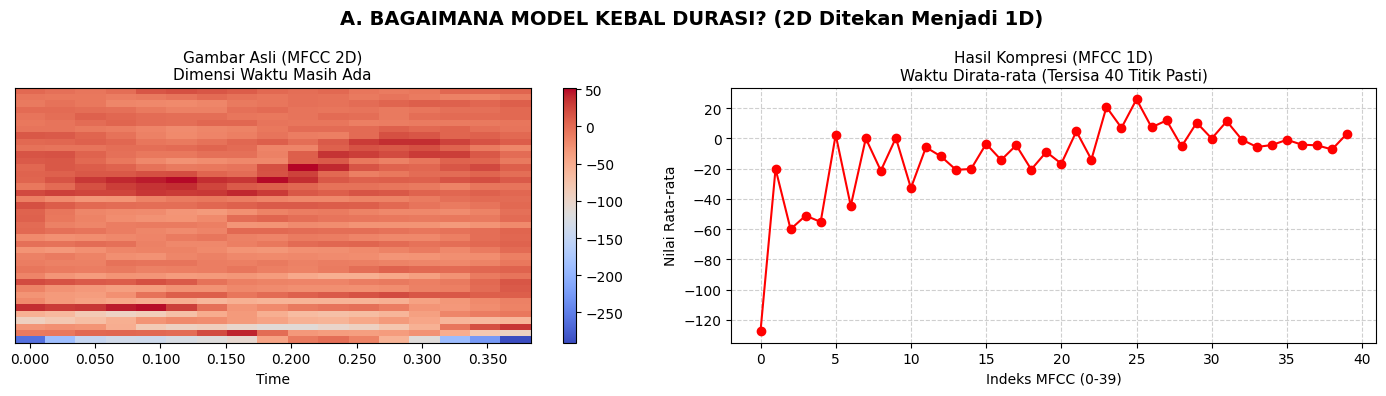

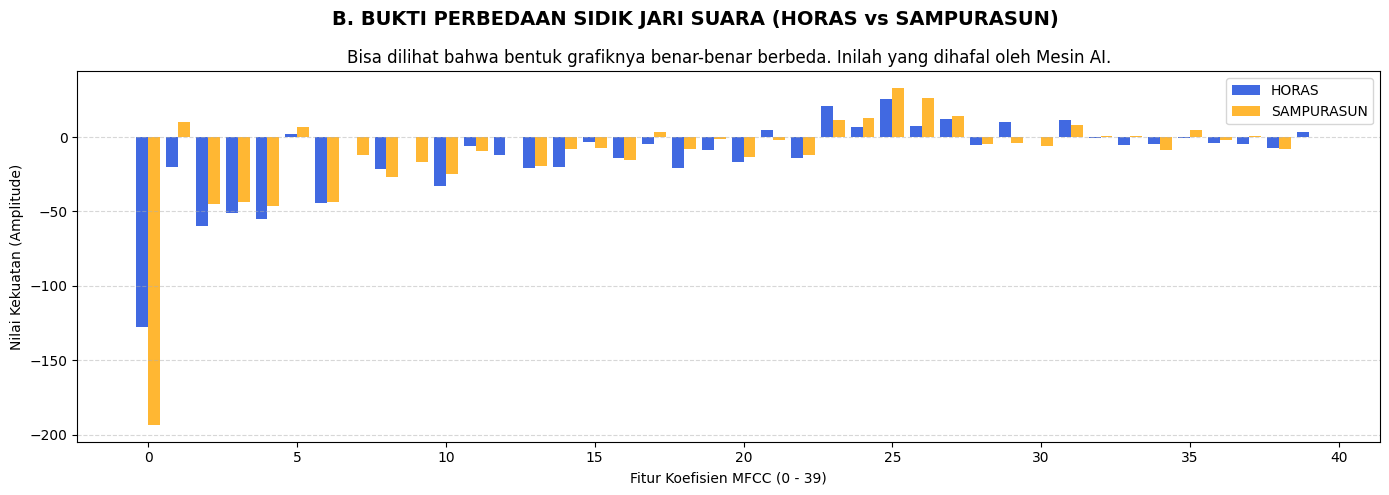

In [9]:
sample_files = []
for cls in ['horas', 'sampurasun']:
    files = glob.glob(f'dataset/augmented/{cls}/*_ori.wav')
    if not files: files = glob.glob(f'dataset/augmented/{cls}/*.wav')
    if files: sample_files.append(files[0])

if len(sample_files) == 2:
    # Ambil sampel
    y_h, sr_h = librosa.load(sample_files[0], sr=16000)
    y_s, sr_s = librosa.load(sample_files[1], sr=16000)
    
    mfcc2d_h = librosa.feature.mfcc(y=y_h, sr=sr_h, n_mfcc=40)
    mfcc2d_s = librosa.feature.mfcc(y=y_s, sr=sr_s, n_mfcc=40)
    
    mfcc1d_h = np.mean(mfcc2d_h.T, axis=0)
    mfcc1d_s = np.mean(mfcc2d_s.T, axis=0)
    
    # ---------------- BAGIAN A: EDUKASI KOMPRESI WAKTU ----------------
    plt.figure(figsize=(14, 4))
    plt.suptitle("A. BAGAIMANA MODEL KEBAL DURASI? (2D Ditekan Menjadi 1D)", fontsize=14, fontweight='bold')
    
    plt.subplot(1, 2, 1)
    librosa.display.specshow(mfcc2d_h, x_axis='time', cmap='coolwarm')
    plt.title('Gambar Asli (MFCC 2D)\nDimensi Waktu Masih Ada', fontsize=11)
    plt.colorbar()
    
    plt.subplot(1, 2, 2)
    plt.plot(mfcc1d_h, color='red', marker='o')
    plt.title('Hasil Kompresi (MFCC 1D)\nWaktu Dirata-rata (Tersisa 40 Titik Pasti)', fontsize=11)
    plt.xlabel('Indeks MFCC (0-39)')
    plt.ylabel('Nilai Rata-rata')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    # ---------------- BAGIAN B: POLA MATEMATIKA ANTAR KELAS ----------------
    plt.figure(figsize=(14, 5))
    plt.suptitle("B. BUKTI PERBEDAAN SIDIK JARI SUARA (HORAS vs SAMPURASUN)", fontsize=14, fontweight='bold')
    
    x_indices = np.arange(40)
    width = 0.4
    
    plt.bar(x_indices - width/2, mfcc1d_h, width, label='HORAS', color='royalblue')
    plt.bar(x_indices + width/2, mfcc1d_s, width, label='SAMPURASUN', color='orange', alpha=0.8)
    plt.xlabel('Fitur Koefisien MFCC (0 - 39)')
    plt.ylabel('Nilai Kekuatan (Amplitude)')
    plt.title('Bisa dilihat bahwa bentuk grafiknya benar-benar berbeda. Inilah yang dihafal oleh Mesin AI.')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Belum ada data untuk memunculkan grafik.")